In [1]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dgidb_genes_dict = {}

In [3]:
LIST_OF_DISEASES = ["BIPOLAR","BREASTCANCER","LEUKEMIA","SCHIZOPHRENIA"]
LIST_OF_DISEASES_LABEL = ["Bipolar Disorder", "Schizophrenia", "Leukemia", "Breast Cancer"]

In [4]:
for d in LIST_OF_DISEASES:
    with open(f"../../Gen_Hypergraph/output/DGIDB_{d}/" + f"gene_to_index.json", "r") as file:
        DGIDB_gene_to_index = json.load(file)
    DGIDB_genes = set(DGIDB_gene_to_index.keys())
    dgidb_genes_dict[d] = DGIDB_genes

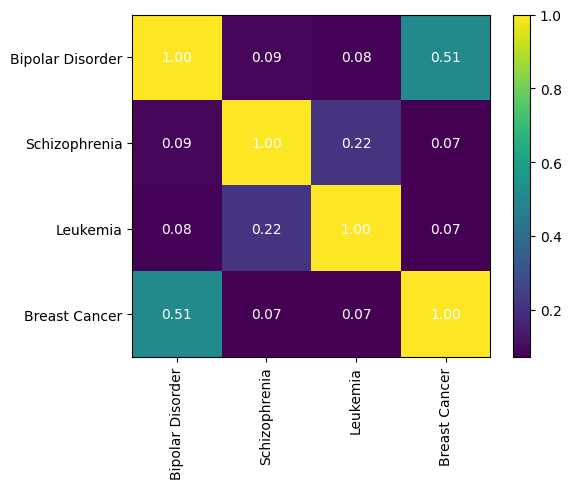

In [5]:
names = list(dgidb_genes_dict.keys())
n = len(names)

M = np.zeros((n, n), dtype=float)

for i in range(n):
    for j in range(n):
        A = dgidb_genes_dict[names[i]]
        B = dgidb_genes_dict[names[j]]
        M[i, j] = len(A & B) / len(A | B) if len(A | B) > 0 else 0

plt.figure(figsize=(6, 5))
im = plt.imshow(M, cmap="viridis", aspect="auto")
plt.colorbar(im)

plt.xticks(range(n), LIST_OF_DISEASES_LABEL, rotation = 90)
plt.yticks(range(n), LIST_OF_DISEASES_LABEL)

# put values in each cell
for i in range(n):
    for j in range(n):
        val = M[i, j]
        text = f"{val:.2f}"
        plt.text(j, i, text, ha="center", va="center", color="white")

plt.tight_layout()
plt.savefig(f"../../Graphs/gene_overlap.pdf", bbox_inches="tight")
plt.show()

In [6]:
# G = nx.Graph()

# # add nodes with size attribute
# for d in disease_list:
#     G.add_node(d, size=len(dgidb_genes_dict[d]))

# # add weighted edges for all pairs
# for i in range(len(disease_list)):
#     for j in range(i + 1, len(disease_list)):
#         w = num_common_genes(disease_list[i], disease_list[j])
#         G.add_edge(disease_list[i], disease_list[j], weight=w)

# # -----------------------------
# # Draw the graph
# # -----------------------------
# pos = nx.spring_layout(G, k=0.5, iterations=200, seed=28)

# node_sizes = [G.nodes[n]['size'] for n in G.nodes]
# edge_weights = [G[u][v]['weight'] for u, v in G.edges]

# plt.figure(figsize=(6, 6))

# w = edge_weights
# w_min, w_max = min(w), max(w)
# edge_widths = [(x - w_min) / (w_max - w_min + 1e-9) * 3 + 0.5 for x in w]

# nx.draw(
#     G,
#     pos,
#     with_labels=True,
#     node_size=node_sizes,
#     width=edge_widths,          # edge width proportional to similarity
#     edge_color='gray',
#     font_size=10
# )

# label_pos = {n: (x, y + 0.07) for n, (x, y) in pos.items()}
# nx.draw_networkx_labels(G, label_pos, labels={n: G.nodes[n]['size'] for n in G.nodes})
# nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
# plt.savefig(f"../../Graphs/gene_overlap.png", bbox_inches="tight")

# plt.show()